# IT2011 – Breast Cancer Wisconsin (Original)

## Member 05 – PCA / Dimensionality Reduction

### Main Focus
- Principal Component Analysis (PCA)
- Dimensionality Reduction
- Explained Variance
- PCA Component Selection
- PCA Loadings

### Dataset
UCI Breast Cancer Wisconsin (Original)

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
# ============================================
# STEP 2 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
# ============================================
# STEP 3 - Load the raw dataset
# ============================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
df = pd.read_csv(url, header=None)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (699, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [8]:
# ============================================
# STEP 4 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

df.head()

,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [9]:
# ============================================
# STEP 5 - Replace '?' with NaN
# ============================================

df = df.replace("?", np.nan)

print("Missing values:")
print(df.isnull().sum())

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [10]:
# ============================================
# STEP 6 - Convert Bare_Nuclei to numeric
# ============================================

df["Bare_Nuclei"] = pd.to_numeric(
    df["Bare_Nuclei"],
    errors="coerce"
)

print(df.dtypes)

Sample_ID                        int64
Clump_Thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object


In [11]:
# ============================================
# STEP 7 - Define the predictor features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

X = df[feature_columns].copy()

print("Number of features:", len(feature_columns))
print("Feature matrix shape:", X.shape)

Number of features: 9
Feature matrix shape: (699, 9)


In [12]:
# ============================================
# STEP 8 - Prepare complete observations for PCA
# ============================================

X_pca_input = X.dropna().copy()

print("Original feature matrix shape:", X.shape)
print("PCA input shape:", X_pca_input.shape)
print("Missing values in PCA input:")
print(X_pca_input.isnull().sum().sum())

Original feature matrix shape: (699, 9)
PCA input shape: (683, 9)
Missing values in PCA input:
0


## What is Dimensionality Reduction?

Dimensionality reduction means reducing the number of input variables while trying to preserve the most important information.

The original dataset contains 9 predictive features.

PCA can transform these 9 features into a smaller number of new variables called Principal Components.

For example:

9 original features
        ↓
      PCA
        ↓
4 principal components

The new principal components are combinations of the original features.

## Why Use PCA?

The EDA showed strong correlations between several features.

For example:

- Uniformity_Cell_Size and Uniformity_Cell_Shape have a strong positive correlation.
- Several other features also contain overlapping information.

PCA can combine correlated information into a smaller number of principal components.

This can:

- Reduce the number of dimensions.
- Reduce redundancy.
- Make the dataset easier to visualize.
- Produce a more compact representation of the features.

PCA does not automatically mean that the discarded components contain no information.
They simply explain less variance than the retained components.

In [13]:
# ============================================
# STEP 11 - Standardize features before PCA
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_pca_input)

print("Scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Scaling completed.
Scaled data shape: (683, 9)


In [14]:
# ============================================
# STEP 12 - Apply PCA to all components
# ============================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print("PCA data shape:", X_pca.shape)

PCA completed.
PCA data shape: (683, 9)


In [15]:
# ============================================
# STEP 13 - Calculate explained variance ratio
# ============================================

explained_variance = pca.explained_variance_ratio_

explained_variance_df = pd.DataFrame({
    "Component": [
        f"PC{i+1}" for i in range(len(explained_variance))
    ],
    "Explained_Variance_Ratio": explained_variance,
    "Explained_Variance_Percentage": explained_variance * 100
})

explained_variance_df

,Component,Explained_Variance_Ratio,Explained_Variance_Percentage
0,PC1,0.655500,65.549993
1,PC2,0.086216,8.621632
2,PC3,0.059917,5.991692
3,PC4,0.051070,5.106972
4,PC5,0.042253,4.225287
5,PC6,0.033542,3.354183
6,PC7,0.032711,3.271141
7,PC8,0.028971,2.897065
8,PC9,0.009820,0.982036


In [16]:
# ============================================
# STEP 14 - Calculate cumulative explained variance
# ============================================

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

cumulative_variance_df = pd.DataFrame({
    "Component": [
        f"PC{i+1}" for i in range(len(cumulative_variance))
    ],
    "Cumulative_Variance_Percentage":
        cumulative_variance * 100
})

cumulative_variance_df

,Component,Cumulative_Variance_Percentage
0,PC1,65.549993
1,PC2,74.171625
2,PC3,80.163316
3,PC4,85.270288
4,PC5,89.495575
5,PC6,92.849758
6,PC7,96.120899
7,PC8,99.017964
8,PC9,100.000000


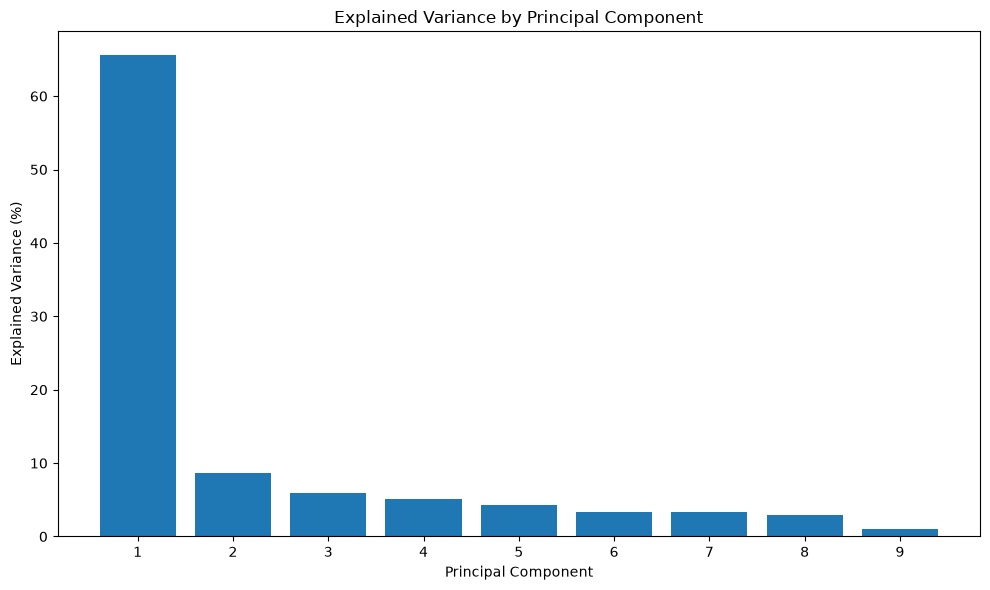

In [17]:
# ============================================
# STEP 15 - Plot explained variance
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance * 100
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Component")

plt.xticks(range(1, len(explained_variance) + 1))

plt.tight_layout()
plt.show()

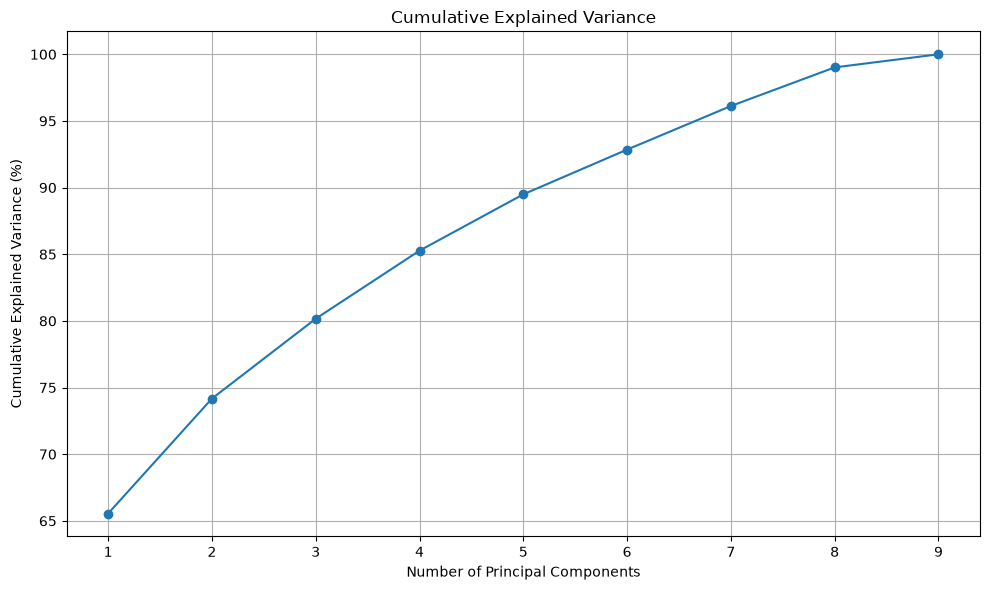

In [18]:
# ============================================
# STEP 16 - Plot cumulative explained variance
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)

plt.tight_layout()
plt.show()

## Selecting the Number of Components

The cumulative explained variance is used to understand how much information is retained as more components are included.

For this dataset:

- PC1 explains approximately 65.56%.
- PC1 + PC2 explain approximately 74.18%.
- PC1 + PC2 + PC3 explain approximately 80.18%.
- PC1 + PC2 + PC3 + PC4 explain approximately 85.35%.
- The first 5 components explain approximately 89.47%.

Four components were selected as the main PCA representation because they retain approximately 85% of the total variance while reducing the number of dimensions from 9 to 4.

This gives a balance between information retention and dimensionality reduction.

In [19]:
# ============================================
# STEP 18 - Create PCA representation with 4 components
# ============================================

pca_4 = PCA(n_components=4)

X_pca_4 = pca_4.fit_transform(X_scaled)

pca_columns = [
    "PC1",
    "PC2",
    "PC3",
    "PC4"
]

X_pca_df = pd.DataFrame(
    X_pca_4,
    columns=pca_columns,
    index=X_pca_input.index
)

print("PCA with 4 components completed.")
print("Reduced data shape:", X_pca_df.shape)

X_pca_df.head()

PCA with 4 components completed.
Reduced data shape: (683, 4)


,PC1,PC2,PC3,PC4
0,-1.470171,-0.104273,0.565685,0.031959
1,1.442046,-0.570141,-0.236601,0.478150
2,-1.592478,-0.076120,-0.048858,0.092388
3,1.479812,-0.528452,0.603048,-1.410827
4,-1.344862,-0.090719,-0.029997,0.338284


In [20]:
# ============================================
# STEP 19 - Verify variance retained by 4 components
# ============================================

variance_4_components = pca_4.explained_variance_ratio_

print("Explained variance by each component:")
for i, variance in enumerate(variance_4_components, start=1):
    print(f"PC{i}: {variance * 100:.2f}%")

print(
    "\nTotal variance retained by 4 components:",
    f"{variance_4_components.sum() * 100:.2f}%"
)

Explained variance by each component:
PC1: 65.55%
PC2: 8.62%
PC3: 5.99%
PC4: 5.11%

Total variance retained by 4 components: 85.27%


In [21]:
# ============================================
# STEP 20 - Calculate PCA loadings
# ============================================

loadings = pd.DataFrame(
    pca_4.components_.T,
    columns=pca_columns,
    index=feature_columns
)

loadings

,PC1,PC2,PC3,PC4
Clump_Thickness,0.302063,-0.140801,0.866372,0.107828
Uniformity_Cell_Size,0.380793,-0.046640,-0.019938,-0.204255
Uniformity_Cell_Shape,0.377583,-0.082422,0.033511,-0.175866
Marginal_Adhesion,0.332724,-0.052094,-0.412647,0.493173
Single_Epithelial_Cell_Size,0.336234,0.164404,-0.087743,-0.427384
Bare_Nuclei,0.335068,-0.261261,0.000691,0.498618
Bland_Chromatin,0.345747,-0.228077,-0.213072,0.013047
Normal_Nucleoli,0.335591,0.033966,-0.134248,-0.417113
Mitoses,0.230206,0.905557,0.080492,0.258988


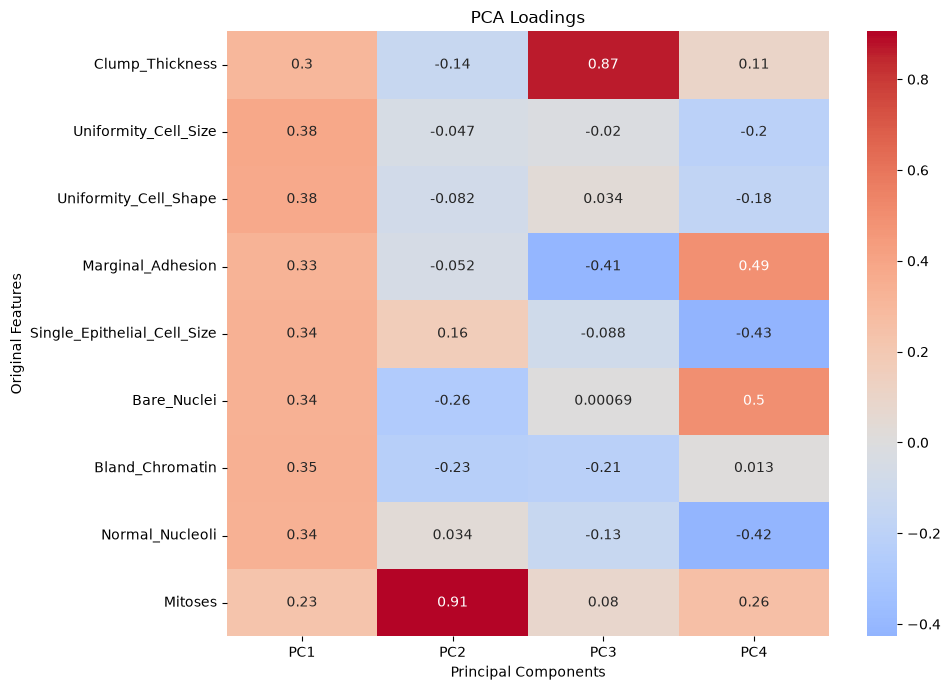

In [22]:
# ============================================
# STEP 21 - Visualize PCA loadings
# ============================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")

plt.tight_layout()
plt.show()

In [23]:
# ============================================
# STEP 22 - Save explained variance results
# ============================================

variance_path = "results/outputs/pca_explained_variance.csv"

explained_variance_df.to_csv(
    variance_path,
    index=False
)

print("Explained variance saved to:")
print(variance_path)

Explained variance saved to:
results/outputs/pca_explained_variance.csv


In [24]:
# ============================================
# STEP 23 - Save cumulative explained variance
# ============================================

cumulative_path = "results/outputs/pca_cumulative_variance.csv"

cumulative_variance_df.to_csv(
    cumulative_path,
    index=False
)

print("Cumulative variance saved to:")
print(cumulative_path)

Cumulative variance saved to:
results/outputs/pca_cumulative_variance.csv


In [25]:
# ============================================
# STEP 24 - Save PCA reduced dataset
# ============================================

pca_data_path = "results/outputs/pca_4_components.csv"

X_pca_df.to_csv(
    pca_data_path,
    index=False
)

print("PCA reduced dataset saved to:")
print(pca_data_path)

PCA reduced dataset saved to:
results/outputs/pca_4_components.csv


In [26]:
# ============================================
# STEP 25 - Save PCA loadings
# ============================================

loadings_path = "results/outputs/pca_loadings.csv"

loadings.to_csv(
    loadings_path
)

print("PCA loadings saved to:")
print(loadings_path)

PCA loadings saved to:
results/outputs/pca_loadings.csv


# PCA / Dimensionality Reduction Summary

## What Was Done?

1. Loaded the Breast Cancer Wisconsin dataset.
2. Replaced `?` with NaN.
3. Converted `Bare_Nuclei` to numeric.
4. Selected the 9 predictor features.
5. Prepared complete observations for the PCA demonstration.
6. Standardized the features using StandardScaler.
7. Applied PCA to all 9 components.
8. Calculated explained variance for each component.
9. Calculated cumulative explained variance.
10. Visualized explained variance.
11. Visualized cumulative explained variance.
12. Selected 4 principal components.
13. Created a reduced dataset containing PC1–PC4.
14. Examined PCA loadings.
15. Saved PCA results and outputs.

## Main Finding

PCA reduced the dimensionality of the dataset from 9 original features to 4 principal components while retaining approximately 85% of the total variance.

This provides a more compact representation of the original features.

## Important Note

PCA components are combinations of the original features and do not have the same direct meaning as the original medical features.

For final machine learning, missing-value imputation, scaling, and PCA should be placed inside a Pipeline and fitted using the training data to prevent data leakage.

In [27]:
# ============================================
# SAVE PCA VISUALIZATION
# ============================================

plt.savefig(
    "results/eda_visualizations/explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [28]:
# ============================================
# SAVE CUMULATIVE PCA VISUALIZATION
# ============================================

plt.savefig(
    "results/eda_visualizations/cumulative_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>